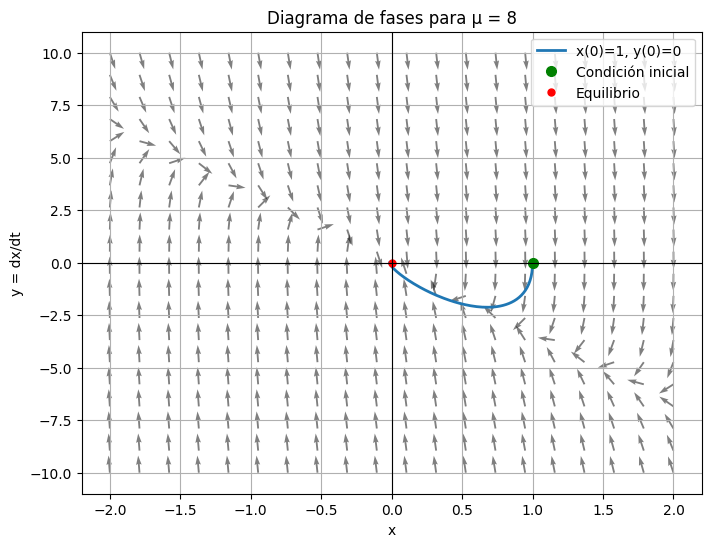

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def sistema(t, estado, mu):
    x, y = estado
    dxdt = y
    dydt = -mu*y - 25*x
    return [dxdt, dydt]

mu = 8
estado_inicial = [1, 0]

# Campo vectorial
x_vals = np.linspace(-2, 2, 20)
y_vals = np.linspace(-10, 10, 20)
X, Y = np.meshgrid(x_vals, y_vals)

dX = Y
dY = -mu*Y - 25*X

norma = np.sqrt(dX**2 + dY**2)
norma[norma == 0] = 1
dX_unit = dX / norma
dY_unit = dY / norma

# Resolver la trayectoria para la condición inicial dada
sol = solve_ivp(
    sistema,
    [0, 10],
    estado_inicial,
    args=(mu,),
    t_eval=np.linspace(0, 10, 1000)
)

# Graficar
plt.figure(figsize=(8, 6))
plt.quiver(X, Y, dX_unit, dY_unit, alpha=0.5)
plt.plot(sol.y[0], sol.y[1], linewidth=2, label="x(0)=1, y(0)=0")
plt.plot(1, 0, 'go', markersize=7, label="Condición inicial")
plt.plot(0, 0, 'ro', markersize=5, label="Equilibrio")

plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel("x")
plt.ylabel("y = dx/dt")
plt.title(f"Diagrama de fases para μ = {mu}")
plt.grid(True)
plt.legend()
plt.show()

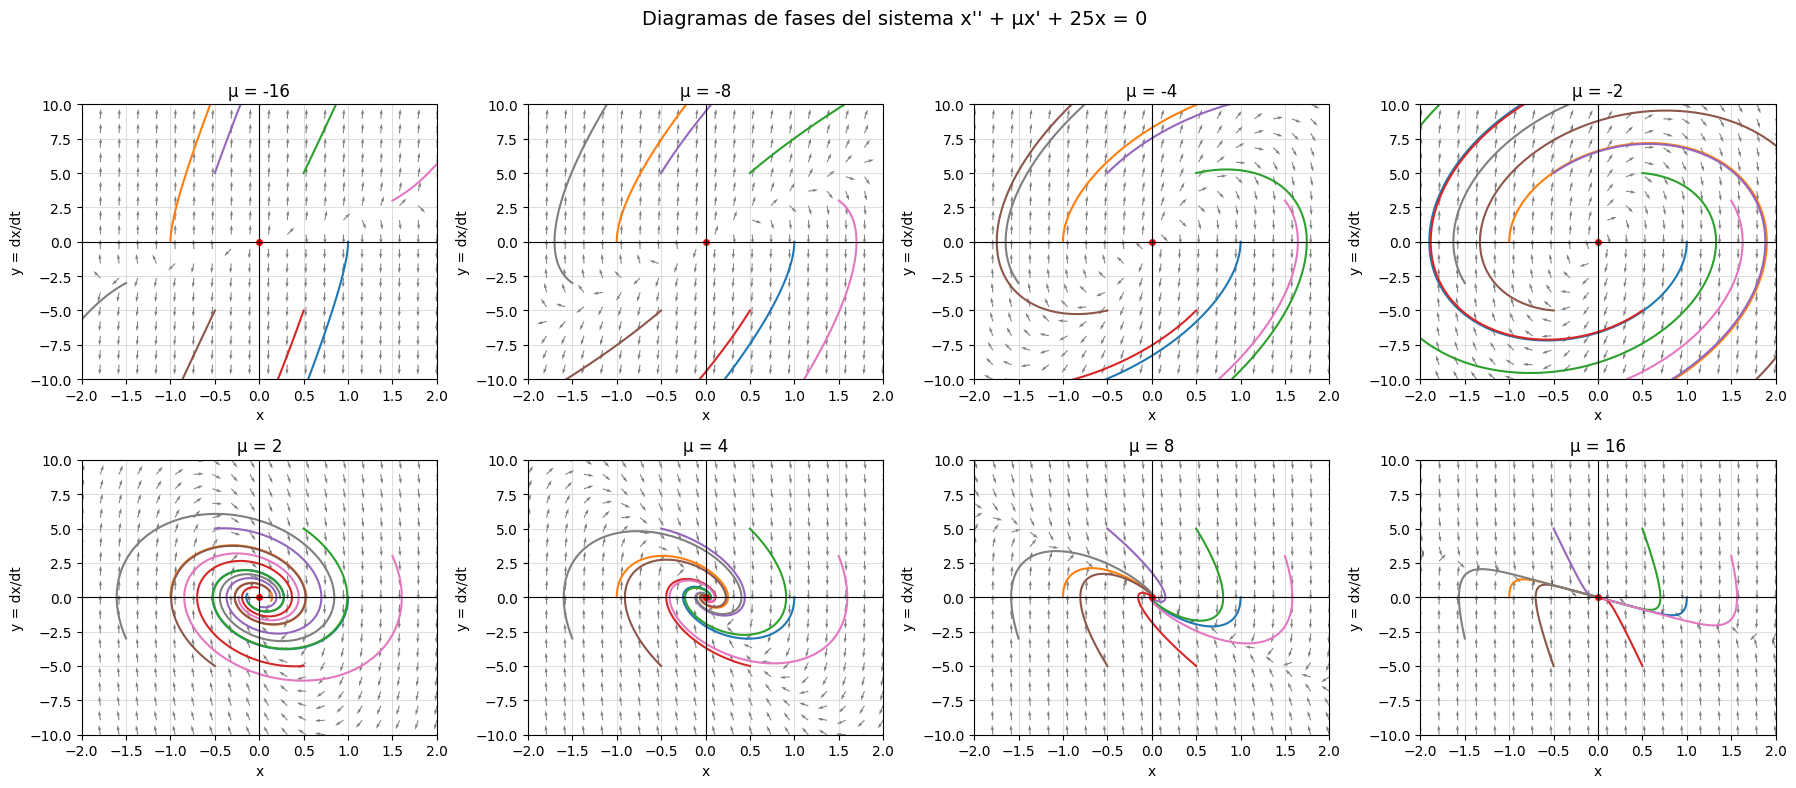

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def sistema(t, estado, mu):
    x, y = estado
    dxdt = y
    dydt = -mu*y - 25*x
    return [dxdt, dydt]

# Grilla del campo vectorial
x_vals = np.linspace(-2, 2, 20)
y_vals = np.linspace(-10, 10, 20)
X, Y = np.meshgrid(x_vals, y_vals)

mus = [-16, -8, -4, -2, 2, 4, 8, 16]

condiciones_iniciales = [
    [1, 0],
    [-1, 0],
    [0.5, 5],
    [0.5, -5],
    [-0.5, 5],
    [-0.5, -5],
    [1.5, 3],
    [-1.5, -3]
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

for ax, mu in zip(axes, mus):
    # Campo vectorial
    dX = Y
    dY = -mu * Y - 25 * X

    norma = np.sqrt(dX**2 + dY**2)
    norma[norma == 0] = 1

    dX_unit = dX / norma
    dY_unit = dY / norma

    ax.quiver(X, Y, dX_unit, dY_unit, alpha=0.5)

    # Trayectorias
    for estado_inicial in condiciones_iniciales:
        sol = solve_ivp(
            sistema,
            [0, 2],   # intervalo más corto
            estado_inicial,
            args=(mu,),
            t_eval=np.linspace(0, 2, 500)
        )
        ax.plot(sol.y[0], sol.y[1], linewidth=1.5)

    # Equilibrio
    ax.plot(0, 0, 'ro', markersize=4)

    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f"μ = {mu}")
    ax.set_xlabel("x")
    ax.set_ylabel("y = dx/dt")
    ax.set_xlim(-2, 2)
    ax.set_ylim(-10, 10)
    ax.grid(True, alpha=0.4)

fig.suptitle("Diagramas de fases del sistema x'' + μx' + 25x = 0", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()